   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

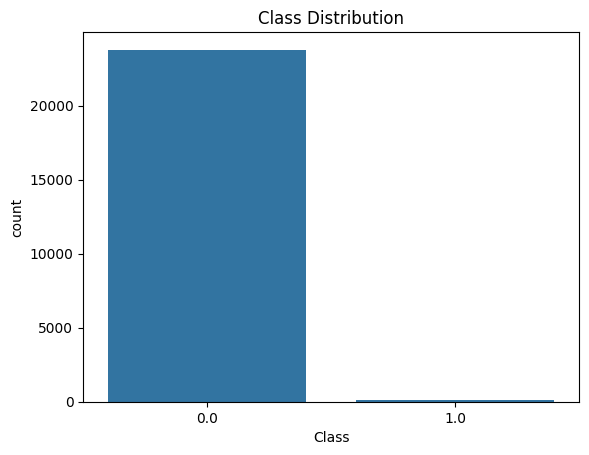

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Credit Card Fraud Detection dataset
url = "creditcard.csv"
df = pd.read_csv(url)

# Explore the dataset
print(df.head())

# Plot the class distribution
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

# Feature scaling
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class', axis=1), df['Class'], test_size=0.2, random_state=42)


In [4]:
from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix
import tensorflow as tf
import numpy as np
import pandas as pd

# Remove NaN values from test labels
mask = ~pd.isna(y_test)
X_test = X_test[mask]
y_test = y_test[mask]

# Build a simple feedforward neural network
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, input_dim=X_train.shape[1], activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

learning_rate = 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Predictions on test set
y_pred = (model.predict(X_test) > 0.5).astype(int)

def evaluate_model(y_true, y_pred):
    print("Precision Score:", precision_score(y_true, y_pred))
    print("Recall Score:", recall_score(y_true, y_pred))
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

evaluate_model(y_test, y_pred)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9861 - loss: 0.0770 - val_accuracy: 0.9979 - val_loss: 0.0053
Epoch 2/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9969 - loss: 0.0110 - val_accuracy: 0.9990 - val_loss: 0.0034
Epoch 3/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9978 - loss: 0.0056 - val_accuracy: 0.9992 - val_loss: 0.0032
Epoch 4/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9983 - loss: 0.0054 - val_accuracy: 0.9992 - val_loss: 0.0032
Epoch 5/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9980 - loss: 0.0043 - val_accuracy: 0.9994 - val_loss: 0.0027
Epoch 6/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9986 - loss: 0.0039 - val_accuracy: 0.9992 - val_loss: 0.0023
Epoch 7/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9987 - loss: 0.0036 - val_accuracy: 0.9992 - val_loss: 0.0019
Epoch 8/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9986 - loss: 0.0033 - val_accuracy: 0.

In [6]:
from sklearn.ensemble import IsolationForest
if_model = IsolationForest(contamination=0.02, random_state=42) #contamination = the proportion of outliers in the data set
if_model.fit(X_train)
if_preds = if_model.predict(X_test)
if_preds[if_preds == 1] = 0  # Normal transactions are labeled as 1, so change it to 0
if_preds[if_preds == -1] = 1  # Fraudulent transactions are labeled as -1, so change it to 1
print("Isolation Forest:")
evaluate_model(y_test, if_preds)

Isolation Forest:
Precision Score: 0.13131313131313133
Recall Score: 0.7647058823529411
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      4754
         1.0       0.13      0.76      0.22        17

    accuracy                           0.98      4771
   macro avg       0.57      0.87      0.61      4771
weighted avg       1.00      0.98      0.99      4771

Confusion Matrix:
[[4668   86]
 [   4   13]]


In [8]:
from sklearn.cluster import KMeans   # <-- missing import

kmeans_model = KMeans(n_clusters=2, random_state=42)
kmeans_model.fit(X_train.values)

kmeans_preds = kmeans_model.predict(X_test.values)

print("\nK-Means:")
evaluate_model(y_test, kmeans_preds)


K-Means:
Precision Score: 0.0023099538009239817
Recall Score: 0.6470588235294118
Classification Report:
              precision    recall  f1-score   support

         0.0       0.33      0.00      0.00      4754
         1.0       0.00      0.65      0.00        17

    accuracy                           0.00      4771
   macro avg       0.17      0.32      0.00      4771
weighted avg       0.33      0.00      0.00      4771

Confusion Matrix:
[[   3 4751]
 [   6   11]]


In [10]:
from sklearn.svm import OneClassSVM   # <-- required import

svm_model = OneClassSVM(kernel='rbf', nu=0.01)

svm_model.fit(X_train)

svm_preds = svm_model.predict(X_test)

# Convert predictions (-1, 1) to (1, 0)
svm_preds[svm_preds == 1] = 0
svm_preds[svm_preds == -1] = 1

print("\nOne-Class SVM:")
evaluate_model(y_test, svm_preds)


One-Class SVM:
Precision Score: 0.1308411214953271
Recall Score: 0.8235294117647058
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      4754
         1.0       0.13      0.82      0.23        17

    accuracy                           0.98      4771
   macro avg       0.57      0.90      0.61      4771
weighted avg       1.00      0.98      0.99      4771

Confusion Matrix:
[[4661   93]
 [   3   14]]
